In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Text(0.5, 1.0, 'Polar Visualization of Circular–Linear Data')

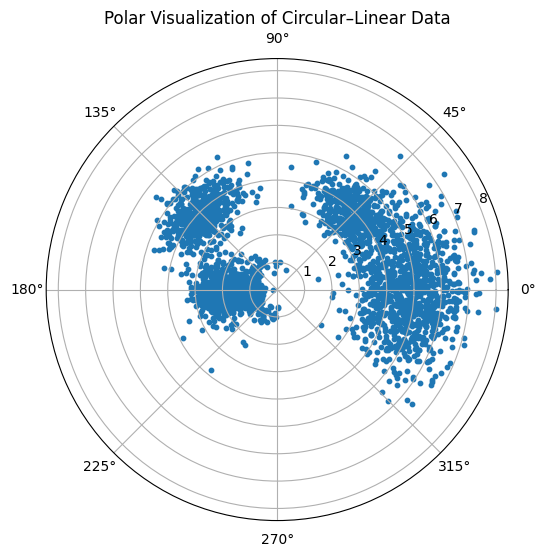

In [54]:
df = pd.read_csv("Data/data1.csv")
df2 = pd.read_csv("Data/data2.csv")
df3 = pd.read_csv("Data/data3.csv")
df4 = pd.read_csv("Data/data4.csv")
all_df = pd.concat([df, df2, df3, df4], ignore_index=True)

plt.figure(figsize=(6, 6))
ax = plt.subplot(111, projection="polar")
ax.scatter(all_df["theta"], all_df["r"], s=10) # s controls marker size
ax.set_title("Polar Visualization of Circular–Linear Data")

In [55]:
theta = all_df["theta"].to_numpy()
r = all_df["r"].to_numpy()

# === 1. Convert polar → Cartesian for KDE ===
x = r * np.cos(theta)
y = r * np.sin(theta)
X = np.column_stack((x, y))


In [ ]:
def gaussian_kernel(x):
    """
    x: (N,)
    """
    return np.exp(-x/2)

# def Epanechnikov_kernel(x):
#     if x>=0 and x < 1:
#         return 1 - x
#     elif x >= 1:
#         return 0
#     else:
#         raise ValueError("x must be non-negative")



def mean_shift(X, kernel, bandwidth, max_iters=100, tol=1e-3):
    """

    Parameters
    ------
    X : ndarray, shape (N, 2)
        Data points.
    bandwidth : float
    max_iters : int
    tol : float

    Returns
    -------
    Y : ndarray, shape (N, 2)
        Converged positions of each point
    """
    X = np.asarray(X, dtype=float)
    N, D = X.shape

    # Initialize each point at its own position
    Y = X.copy()

    for it in range(max_iters):
        # print(f"Iteration {it+1}/{max_iters}")

        # For each point y_i, compute weighted mean of all X_j
        Y_new = np.zeros_like(Y)
        for i in range(N):
     
            diff = X - Y[i]                  # shape (N, D)
            dist = np.linalg.norm(diff, axis=1) # shape (N,)
            scale_diff = np.square(dist / bandwidth)
            # Compute weights
            if kernel == "gaussian":
                weights = gaussian_kernel(scale_diff)  # shape (N,). The derivation of Gaussian kernel is itself.
            else:    
                weights = np.asarray((scale_diff < 1)).astype(float) # The derivation of Epanechnikov kernel is a flat kernel.
                
            w_sum = np.sum(weights)

            Y_new[i] = np.sum(weights[:, None] * X, axis=0) / w_sum

        # Check convergence
        shifts = np.linalg.norm(Y_new - Y, axis=1)
        max_shift = np.max(shifts)

        Y = Y_new

        if max_shift < tol:
            print("Converged")
            break

    return Y

# ============================================================
# Turn converged points into cluster labels (merge close modes)
# ============================================================
def assign_clusters(modes, merge_tol=0.3):
    """
    Parameters
    -------
    modes: ndarray, shape (N, 2)
            converged positions per point
    merge_tol: float
            distance below which two modes are considered the same

    Returns
    -------
    labels : ndarray, shape (N,)
        Cluster index for each point: (0..K-1)
    centers : ndarray, shape (K, 2)
        Unique cluster centers.
    """
    N, _ = modes.shape
    labels = -np.ones(N, dtype=int)
    centers = []

    for i in range(N):
        # First point is assigned as mode 1
        if i == 0 and len(centers) == 0:
            centers.append(modes[i])
            labels[i] = 0
            continue

        # Compare this mode to existing centers
        dists = np.linalg.norm(modes[i] - np.vstack(centers), axis=1)
        idx = np.argmin(dists)
        if dists[idx] < merge_tol:
            labels[i] = idx
        else:
            centers.append(modes[i])
            labels[i] = len(centers) - 1

    return labels, np.vstack(centers)



--- Testing: Kernel=epanechnikov, Bandwidth=0.5 ---
Converged
Found 75 clusters.


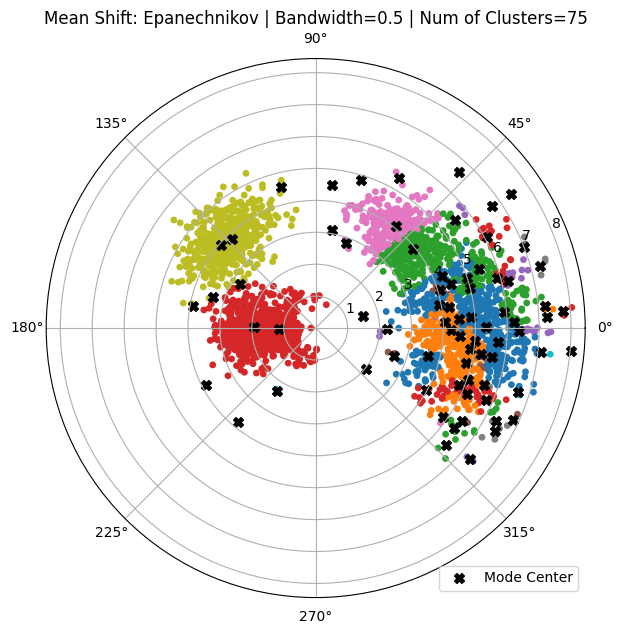


--- Testing: Kernel=epanechnikov, Bandwidth=1.0 ---
Converged
Found 7 clusters.


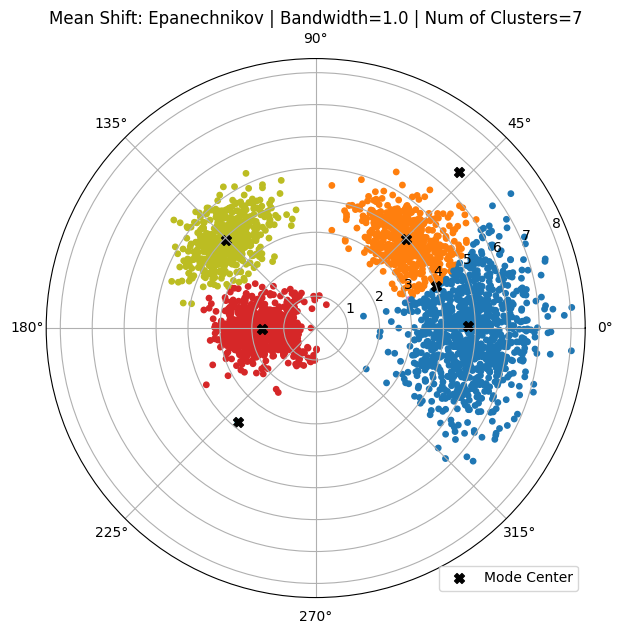


--- Testing: Kernel=epanechnikov, Bandwidth=1.5 ---
Converged
Found 4 clusters.


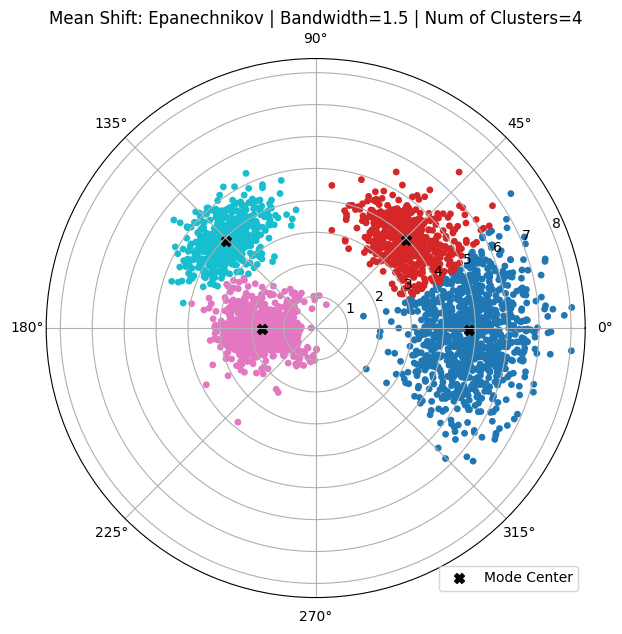


--- Testing: Kernel=epanechnikov, Bandwidth=2.0 ---
Converged
Found 5 clusters.


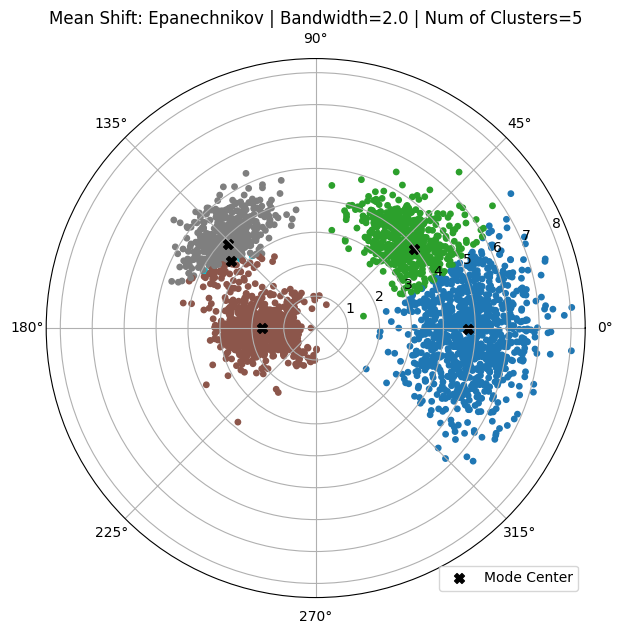


--- Testing: Kernel=gaussian, Bandwidth=0.5 ---
Found 4 clusters.


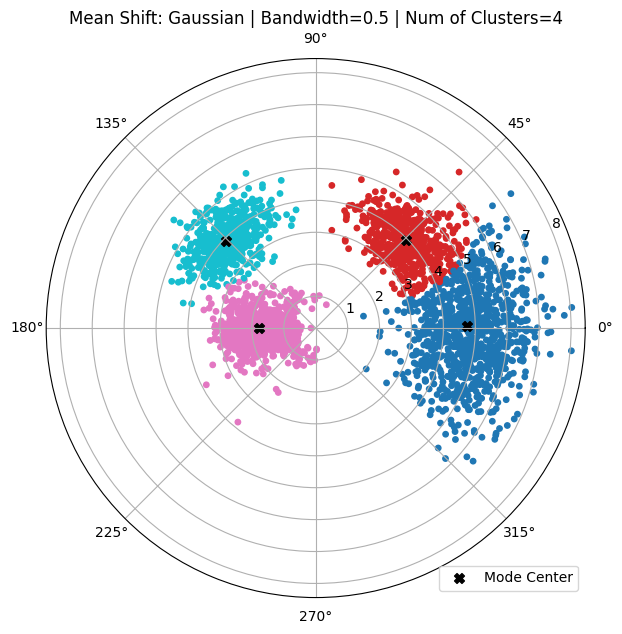


--- Testing: Kernel=gaussian, Bandwidth=1.0 ---
Found 4 clusters.


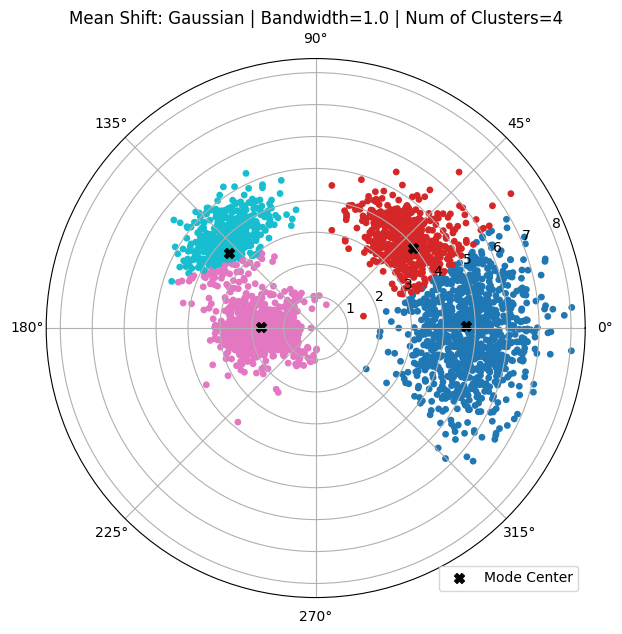


--- Testing: Kernel=gaussian, Bandwidth=1.5 ---
Converged
Found 2 clusters.


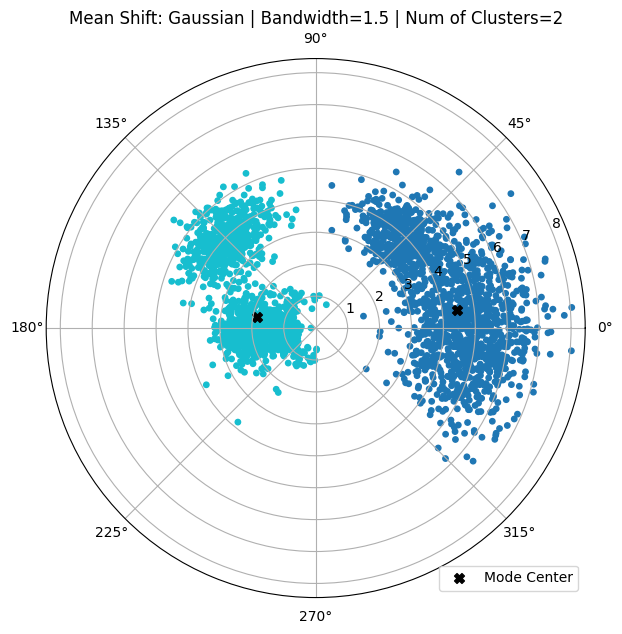


--- Testing: Kernel=gaussian, Bandwidth=2.0 ---
Converged
Found 2 clusters.


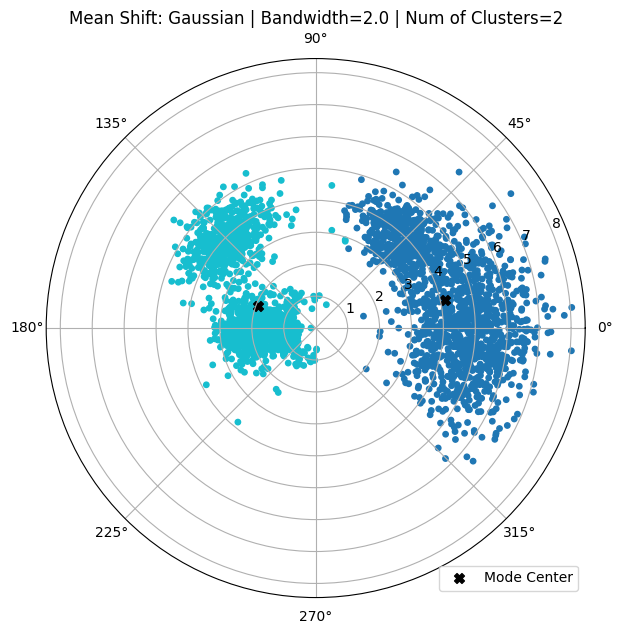


           TEST SUMMARY               
Kernel: epanechnikov    BW: 0.5   Clusters Found: 75
Kernel: epanechnikov    BW: 1.0   Clusters Found: 7
Kernel: epanechnikov    BW: 1.5   Clusters Found: 4
Kernel: epanechnikov    BW: 2.0   Clusters Found: 5
Kernel: gaussian        BW: 0.5   Clusters Found: 4
Kernel: gaussian        BW: 1.0   Clusters Found: 4
Kernel: gaussian        BW: 1.5   Clusters Found: 2
Kernel: gaussian        BW: 2.0   Clusters Found: 2


In [ ]:
kernel_types = ["epanechnikov", "gaussian"]
bandwidth_values = [0.5, 1.0,1.5, 2.0] # Test a range of bandwidths
merge_tolerance = 0.3 

results = []
fig_count = 1

for kernel in kernel_types:
    for bandwidth in bandwidth_values:
        print(f"\n--- Testing: Kernel={kernel}, Bandwidth={bandwidth} ---")
        
        # Mean Shift Execution
        Y = mean_shift(X, kernel=kernel, bandwidth=bandwidth, max_iters=50, tol=1e-3)
        # Cluster Assignment
        labels, centers = assign_clusters(Y, merge_tol=merge_tolerance)
        all_df[f"cluster_{kernel}_{bandwidth}"] = labels

        num_clusters = len(centers)
        print(f"Found {num_clusters} clusters.")
        results.append({
            'kernel': kernel,
            'bandwidth': bandwidth,
            'clusters': num_clusters,
            "labels": labels,
            "centers": centers
        })
        
        plt.figure(figsize=(7, 7))
        ax = plt.subplot(111, projection="polar")
        sc = ax.scatter(theta, r, c=labels, s=15, cmap="tab10")
        
        # Plot centers 
        center_r = np.linalg.norm(centers, axis=1)
        center_theta = np.arctan2(centers[:, 1], centers[:, 0])
        ax.scatter(center_theta, center_r, marker='X', s=50, c='black', label="Mode Center")

        # plt.colorbar(sc, ax=ax, label="Cluster ID")
        title = f"Mean Shift: {kernel.capitalize()} | Bandwidth={bandwidth} | Num of Clusters={num_clusters}"
        ax.set_title(title)
        plt.legend(loc='lower right')
        # plt.savefig(f"Result/mean_shift_{kernel}_bw{bandwidth}.png")
        plt.show()

# 6. Print Summary Results
print("\n======================================")
print("           TEST SUMMARY               ")
print("======================================")
for res in results:
    print(f"Kernel: {res['kernel']:<15} BW: {res['bandwidth']:<5} Clusters Found: {res['clusters']}")

In [58]:
def calculate_cluster_statistics(X, labels, centers) -> dict:
    """
    Parameters:
    - X : The original data points in Cartesian coordinates (N, D).
    - labels : The cluster label assigned to each point (N,).
    - centers: shape (K, 2)

    """
    cluster_stats = {}
    unique_labels = np.unique(labels)
    for lab in unique_labels:
        #  Select the actual data points belonging to this cluster
        pts = X[labels == lab]
        N_k = len(pts)
        # --- Cartesian Statistics ---
        # Mean vector
        mean_vec = np.mean(pts, axis=0)  # shape (2,)
        cov_mat = np.cov(pts, rowvar=False) 

        # --- Polar statistics --
        mean_r = np.linalg.norm(mean_vec)
        mean_theta = np.arctan2(mean_vec[1],mean_vec[0])

        center_r = np.linalg.norm(centers[lab])
        center_theta = np.arctan2(centers[lab][1],centers[lab][0])
        cluster_stats[lab] = {
            "count": N_k,
            "mean_cartesian": mean_vec,
            "covariance_cartesian": cov_mat,
            "center_cartesian": centers[lab],
            "mean_polar": (mean_r, mean_theta),
            "center_polar": (center_r, center_theta)
        }

    return cluster_stats

for item in results:
    if item.get('kernel') == 'gaussian' and item.get('bandwidth') == 0.5:
        gaussian_result = item
    elif item.get('kernel') == 'epanechnikov' and item.get('bandwidth') == 1.5:
        epanechnikov_result = item

gaussian_cluster_stats = calculate_cluster_statistics(X, gaussian_result.get("labels"), gaussian_result.get("centers"))
epanechnikov_cluster_stats = calculate_cluster_statistics(X, epanechnikov_result.get("labels"), epanechnikov_result.get("centers"))
# ---- Print results ----
for lab, info in epanechnikov_cluster_stats.items():
    print(f"Cluster {lab}:")
    print(f"  Number of points: {info['count']}")
    print(f"  Mean (x,y): {info['mean_cartesian']}")
    print(f"  center_cartesian: {info['center_cartesian']}")
    print(f"  Covariance cartesian:\n{info['covariance_cartesian']}")
    print(f"  Mean (r, theta): {info['mean_polar']}")
    print(f"  center_polar: {info['center_polar']}")
    print()

for lab, info in gaussian_cluster_stats.items():
    print(f"Cluster {lab}:")
    print(f"  Number of points: {info['count']}")
    print(f"  Mean (x,y): {info['mean_cartesian']}")
    print(f"  center_cartesian: {info['center_cartesian']}")
    print(f"  Covariance cartesian:\n{info['covariance_cartesian']}")
    print(f"  Mean (r, theta): {info['mean_polar']}")
    print(f"  center_polar: {info['center_polar']}")
    print()


Cluster 0:
  Number of points: 941
  Mean (x,y): [ 4.83619542 -0.18628835]
  center_cartesian: [ 4.81056482 -0.06728423]
  Covariance cartesian:
[[0.99448511 0.17433776]
 [0.17433776 1.60705282]]
  Mean (r, theta): (np.float64(4.839781965272815), np.float64(-0.038500572761999655))
  center_polar: (np.float64(4.811035341153613), np.float64(-0.013985850757245214))

Cluster 1:
  Number of points: 559
  Mean (x,y): [2.87831887 2.75703816]
  center_cartesian: [2.83342356 2.74291029]
  Covariance cartesian:
[[ 0.64987758 -0.16085789]
 [-0.16085789  0.48125654]]
  Mean (r, theta): (np.float64(3.9857218793580302), np.float64(0.763880096577635))
  center_polar: (np.float64(3.943582877385874), np.float64(0.7691679085736635))

Cluster 2:
  Number of points: 900
  Mean (x,y): [-1.67191493 -0.02132954]
  center_cartesian: [-1.68650203 -0.02069295]
  Covariance cartesian:
[[ 0.48643177 -0.02407095]
 [-0.02407095  0.28348799]]
  Mean (r, theta): (np.float64(1.6720509829310137), np.float64(-3.12883579